# Optimising Fidelity of Quantum Maps

An example of how one can compute and optimise the fidelity between quantum operations. This code generates a process tensor, which is then combined with a set of propagators to obtain the dynamical map $\Lambda (t,0)$ , which satisfies 
\begin{equation}
\rho_S(t) = \Lambda (t,0) \rho_S(0)
\end{equation}
where $\rho_S (t)$ is the reduced density matrix of a system coupled to a Gaussian bath. Gradient descent is then applied on the system propagators to find $\tilde{\Lambda} (t,0)$: the map that most faithfully reproduces some unitary $U(t,0)$ according to any measure between quantum operations $F(\Lambda,U)$.

## 1. Setup: Generate PT and define system Hamiltonian

In [2]:
import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
import time

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':50,
                 'steps':100, 
                 'dkmax':50,
                 'epsrel':10**(-6),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131}


omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

initial_state = op.spin_dm('x+')
target_state = op.spin_dm('x-')
target_derivative = target_state.T

t_list = np.linspace(0,t_max,num_steps+1)


In [3]:
import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
import numpy as np
import matplotlib.pyplot as plt

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
correlations_10K =oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature*10)

bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=dkmax)

pt=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_tebd = pt.get_process_tensor()

building influence functional:  32%|███▏      | 16/50 [00:00<00:00, 146.67it/s]

building influence functional: 100%|██████████| 50/50 [00:01<00:00, 33.55it/s] 

rank  142 (142, 4, 142)


In [4]:
# parameters converged for 10K

epsrel_10K=10**(-4)

parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel_10K,dkmax=num_steps)
bath_10K = oqupy.Bath(op.sigma("z")/2.0, correlations_10K)
pt_10K=TTITempo(bath_10K,start_time=0.0,parameters=parameters)
process_tensor_tebd_10K = pt_10K.get_process_tensor()

building influence functional: 100%|██████████| 100/100 [00:00<00:00, 1515.98it/s]

rank  11 (11, 4, 11)


--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:04
Elapsed time: 4.1s
--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:03
Elapsed time: 3.7s
0.9824390715310551
 87.0%   87 of  100 [##################################------] 00:03:27

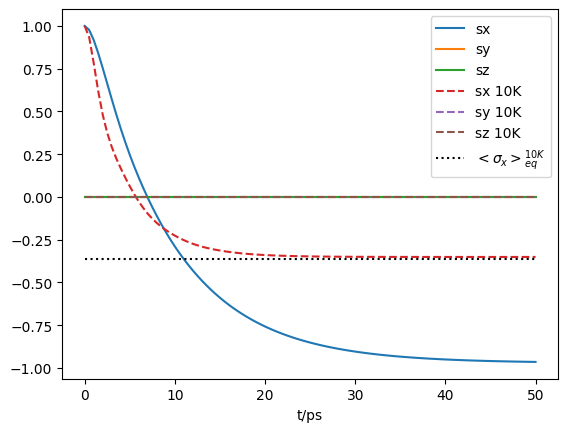

--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:04
Elapsed time: 4.9s
--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:03
Elapsed time: 3.1s
0.9840695573970226
 69.0%   69 of  100 [###########################-------------] 00:05:35

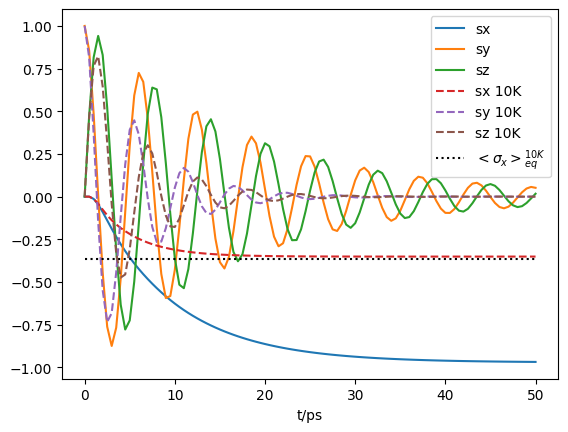

--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:03
Elapsed time: 3.8s
--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:03
Elapsed time: 3.2s
0.9840695573970344


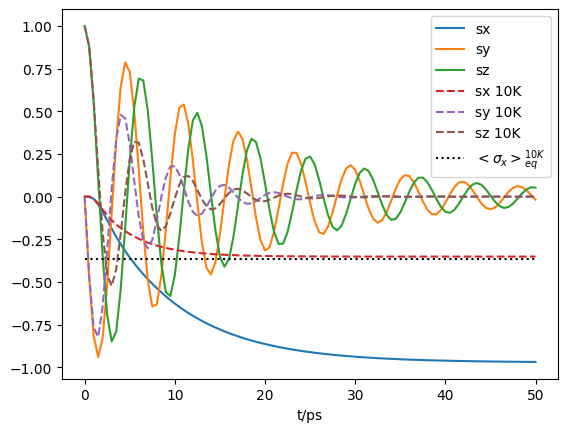

 87.0%   87 of  100 [##################################------] 00:04:44

In [16]:
def hamiltonian_t(t):
    return pt_parameters['omega_cutoff']*op.sigma('x')/2*1

system_td = oqupy.TimeDependentSystem(hamiltonian_t)

#Rho_0=oqupy.operators.spin_dm('z-')

basis_states=[op.SPIN_DM["x+"],op.SPIN_DM["y+"],op.SPIN_DM["z+"]] 

for state in basis_states:
    dynamics = oqupy.compute_dynamics(
        process_tensor=process_tensor_tebd,        
        system=system_td,
        initial_state=np.array(state),
        start_time=0,
        num_steps=num_steps)
    
    dynamics_10K = oqupy.compute_dynamics(
    process_tensor=process_tensor_tebd_10K,        
    system=system_td,
    initial_state=np.array(state),
    start_time=0,
    num_steps=num_steps)
    

    t, s_x_10K = dynamics_10K.expectations(op.sigma('x'), real=True)
    t,s_z_10K = dynamics_10K.expectations(op.sigma('z'), real=True)
    t, s_y_10K = dynamics_10K.expectations(op.sigma('y'), real=True)

    t, s_x = dynamics.expectations(op.sigma('x'), real=True)
    t,s_z = dynamics.expectations(op.sigma('z'), real=True)
    t, s_y = dynamics.expectations(op.sigma('y'), real=True)

    state_fidelity=np.sum(dynamics.states[-1]*target_state).real
    print(state_fidelity)

    plt.plot(t,s_x,label='sx')
    plt.plot(t,s_y,label='sy')
    plt.plot(t,s_z,label='sz')

    plt.plot(t,s_x_10K,label='sx 10K',linestyle='dashed')
    plt.plot(t,s_y_10K,label='sy 10K',linestyle='dashed')
    plt.plot(t,s_z_10K,label='sz 10K',linestyle='dashed')

    plt.hlines(y=-np.tanh(omega_cutoff/(2*temperature*10)),xmin=0,xmax=t[-1],color='black',linestyle='dotted',label="$<\sigma_x >_{eq}^{10K}$")

    plt.xlabel('t/ps')
    plt.legend()
    plt.show()



## 2. State gradient calculation

--> Compute forward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.8s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.9s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:08
Elapsed time: 8.1s
final state fidelity:  0.9824390715310539


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


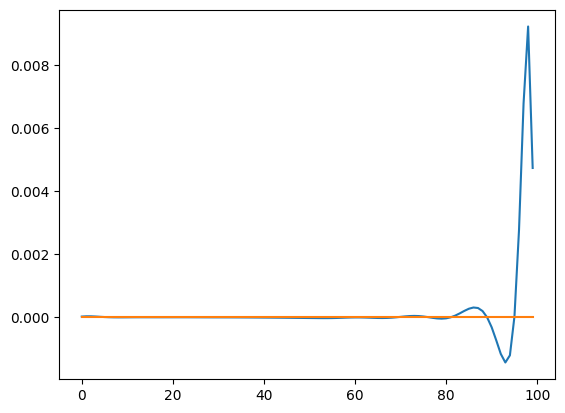

 87.0%   87 of  100 [##################################------] 00:05:06

In [17]:
from oqupy.gate_gradient import compute_dynamical_map,compute_dynamical_map_and_grad
from oqupy.gradient import state_gradient

def discrete_hamiltonian(hx,hz):
    return hx*op.sigma('x')/2 + hz*op.sigma('z')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

h_z = np.ones(2*num_steps)*0
#h_x = np.linspace(0,1,2*num_steps)*1
h_x=np.ones(2*num_steps)*1

parameters = np.vstack((h_x,h_z)).T
parameters.shape

gradient=state_gradient(system=system,
                        initial_state=initial_state,
                        target_derivative=target_derivative,
                        process_tensors=[process_tensor_tebd],
                        parameters=parameters,
                        num_steps=num_steps)

grad_tot=gradient['gradient']

fin_state_fid=np.sum(gradient['final_state']*target_state).real
print("final state fidelity: ",fin_state_fid)

for i in range(0,grad_tot.shape[0],2):
    grad_tot[i,:]=grad_tot[i,:]+grad_tot[i+1,:]   

grad_tot=grad_tot[0::2]

plt.plot(grad_tot[:,0])
plt.plot(grad_tot[:,1])
plt.show()


# 3. Dynamical map and dynamical map derivative calculation

Here, we calculate $\Lambda(t,0)$ and $\frac{\partial{\Lambda(t,0)}}{\partial c_{\alpha'} (t)}$ , where $\{ c_{\alpha'} (t) \}$ are a set of $2MN$ complex/real numbers parameterising the system Hamiltonian at each half time-step. Here $N$ is the number of (full) timesteps and $M$ is the number of independent parameters.

To do this, we first calculate $\Lambda(t,0)$ and $\frac{\partial{\Lambda(t,0)}}{U (t)}$, as shown below.

In [18]:
map_list,grad_list=compute_dynamical_map_and_grad(system,
        [process_tensor_tebd],
        parameters,
        dt,
        start_time=0,
        num_steps=num_steps)

print(np.shape(map_list))

 69.0%   69 of  100 [###########################-------------] 00:07:11(100, 4, 4)


 87.0%   87 of  100 [##################################------] 00:06:30

Then each tensor in `grad_list` is combined with a half time-step propagator and derivative of half time-step propagator with respect to the parameter at that half time-step in order to give $\frac{\partial{\Lambda(t,0)}}{\partial c_{\alpha'} (t)}$.

In [ ]:
from oqupy.gate_gradient import gate_chain_rule

prop_derivs=system.get_propagator_derivatives(dt,parameters)
props=system.get_propagators(dt,parameters)

prop_derivs_test=lambda x : (props(x),props(x))

num_parameters=parameters.shape[1]

# testing what happens if we put propagators into chain rule instead of derivatives (should just reproduce map at final time)
dyn_map_test=gate_chain_rule(grad_list,prop_derivs_test,props,num_steps,num_parameters) 

# derivative with respect to system parameters
dyn_map_derivatives=gate_chain_rule(grad_list,prop_derivs,props,num_steps,num_parameters)

print(dyn_map_derivatives.shape)

--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.5s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:08
Elapsed time: 8.4s
(200, 2, 4, 4)


 87.0%   87 of  100 [##################################------] 00:06:54

## 4. Map Similarity Measures
In order to compare different quantum maps, we need to choose a measure that will appropriately distinguish them. Here, we will be interesting in comparing the final map $\Lambda(T,0)$, which pulls all states towards the ground state of the Hamiltonian $\ket{x-}$, with the identity map $1\!\!1$.

### 4.1 Average fidelity for a quantum operation
The first measure we consider is specifically designed for comparing quantum operations. Derived in [this](https://arxiv.org/abs/quant-ph/0701138) paper, the measure distinguishes any CPTP map $\mathcal{G}$ with a given unitary $U_0$ by comparing their effect on the set of all pure states $\{ \ket{\psi} \bra{\psi} \}$. In equations:

\begin{align*}
F&=\int_{S^{2n-1}} \bra{\psi} U_0^\dag\space \mathcal{G} (\ket{\psi} \bra{\psi}) \space U_0 \ket{\psi} dV \\
&= \frac{1}{n(n+1)} \{ \text{Tr} (\sum_k M_k^\dagger M_k) + \sum_k |\text{Tr} (M_k)|^2 \},
\end{align*}
where $M_k=U_0 G_k $ and $\{ G_k \}$ are a set of Krauss operators reproducing the map $\mathcal{G}$.

In [39]:
# ----- defining target unitary HERE ----
target_unitary=np.identity(2)

In [40]:
from scipy.linalg import svd

import numpy as np
import numdifftools as nd
import matplotlib.pyplot as plt
from numdifftools import Jacobian

# ---- Fidelity over pure states
# ---------------- Superoperator -> Choi ----------------
def superop_to_choi_numpy(map_matrix):
    """
    map_matrix: 4x4 superoperator acting on 2x2 density matrix (flattened)
    """
    d = 2
    choi_matrix = np.zeros((d*d, d*d), dtype=np.complex128)
    for i in range(d):
        for j in range(d):
            e_ij = np.zeros((d,d), dtype=map_matrix.dtype)
            e_ij[i,j] = 1.0
            phi_e_ij = map_matrix @ e_ij.flatten()  # shape (4,)
            phi_e_ij_mat = phi_e_ij.reshape((d,d))
            choi_matrix += np.kron(e_ij, phi_e_ij_mat)
    return choi_matrix

# ---------------- Choi -> Kraus ----------------
def choi_to_kraus_numpy(choi):
    vals, vecs = np.linalg.eigh(choi)
    kraus_ops = []
    for val, vec in zip(vals, vecs.T):
        if val > 1e-20:
            K = np.sqrt(val) * vec.reshape((2,2))
            kraus_ops.append(K)
    return kraus_ops

# ---------------- Rotation fidelity ----------------
def rotation_fidelity_numpy(unitary, kraus_ops):
    d = 2
    first_term = np.zeros((d,d), dtype=np.complex128)
    second_term = 0.0
    for kraus in kraus_ops:
        M = unitary.conj().T @ kraus
        first_term += M.conj().T @ M
        second_term += abs(np.trace(M))**2
    first_term = np.trace(first_term)
    fidelity = (first_term + second_term) / (d*(d+1))
    return fidelity.real

# ---------------- Fidelity wrapper ----------------
def fidelity_wrapper_numpy(map_matrix, target_unitary):
    choi = superop_to_choi_numpy(map_matrix)
    kraus = choi_to_kraus_numpy(choi)
    return rotation_fidelity_numpy(target_unitary, kraus)



 87.0%   87 of  100 [##################################------] 00:18:13

### 4.2 Trace distance
Since we are working in vectorised Liouville space, the dynamical map here is simply a $d^2$ by $d^2$ matrix, where $d$ is the Hilbert space dimension. As a result, we can use standard distances between matrices, like the trace distance, defined as 
\begin{align*}
T(\rho,\sigma)&= \frac{1}{2} \text{Tr} [  (\rho-\sigma)^\dagger (\rho-\sigma) ] \\
&= \frac{1}{2}\sum_{i=1}^r | \lambda_i |
\end{align*}
where $\lambda_i$ is the $i$ th eigenvalue of $\rho-\sigma$ and $r$ the rank. 

Since the unitarys we wish to compare with our maps act on a Hilbert space, we will need to convert them to superoperators before using this formula (e.g. $1\!\!1 \space \rightarrow \space 1\!\!1 \otimes 1\!\!1$).

In [ ]:
def unitary_to_superop(U):
    
    return np.kron(U, np.conj(U))

def superop_trace_distance(M, U):
    """Trace distance between map (superop) and unitary channel."""
    S_U = unitary_to_superop(U)
    diff = M - S_U
    svals = svd(diff, compute_uv=False)
    return 0.5*np.sum(np.abs(svals))/2

 87.0%   87 of  100 [##################################------] 00:18:25

Below, we show the change in the two measures as a function of time when comparing $\Lambda(t,0)$ and the identity map.

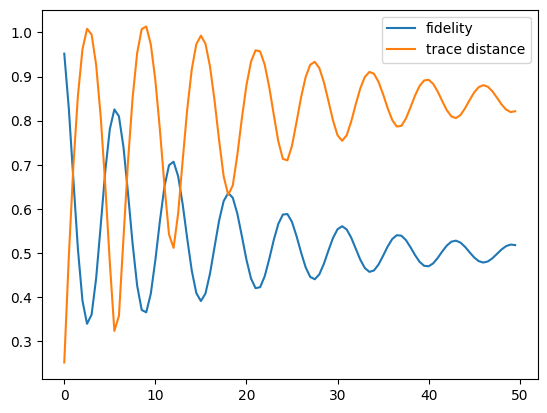

3.3885831712133685e-05
0.51794232883617


 69.0%   69 of  100 [###########################-------------] 00:20:26

In [42]:
fidelitys=[]
trace_distance=[]
for i,map in enumerate(map_list):

    choi_matrix=superop_to_choi_numpy(map)
    kraus_ops=choi_to_kraus_numpy(choi_matrix)

    fidelitys.append(rotation_fidelity_numpy(target_unitary,kraus_ops).real)

    trace_distance.append(superop_trace_distance(map,target_unitary).real)


plt.plot(t[:-1],fidelitys,label='fidelity')
plt.plot(t[:-1],trace_distance,label='trace distance')
#plt.plot(t[:-1],trace_distance)
plt.legend()
plt.show()
I = np.eye(2)
residual = np.sum([K.conj().T @ K for K in kraus_ops], axis=0) - I
print(np.linalg.norm(residual))

print(fidelitys[-1])

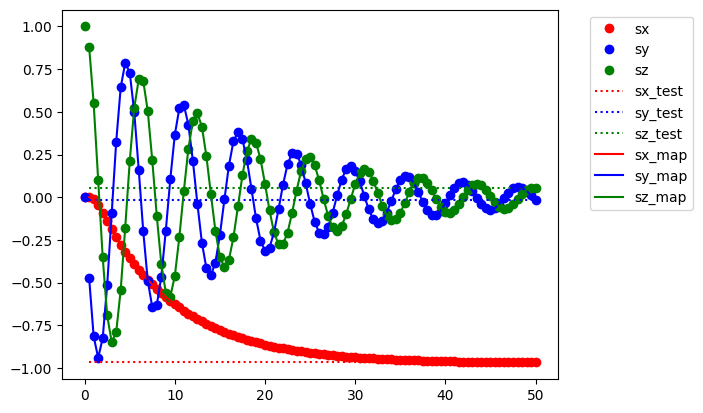

 87.0%   87 of  100 [##################################------] 00:18:49

In [43]:
# sanity checking dynamics and grad :

sx_map=[]
sy_map=[]
sz_map=[]

sx_test=[]
sy_test=[]
sz_test=[]


test_map=dyn_map_test[:,0,:,:]


for i,map in enumerate(map_list):
    vec_Rho=np.array(basis_states[2]).reshape(4)
    # testing map
    final_Rho=map.T@vec_Rho
    # testing grad
    test_Rho=test_map[2*i,:,:].T@vec_Rho

    #final_Rho_a=vec_Rho.T@superoperator
    # Reshape the final state back to a density matrix
    final_Rho = final_Rho.reshape((2, 2))
    sx_map.append(np.trace(final_Rho@op.sigma('x')).real)
    sy_map.append(np.trace(final_Rho@op.sigma('y')).real)
    sz_map.append(np.trace(final_Rho@op.sigma('z')).real)

    test_Rho = test_Rho.reshape((2, 2))
    sx_test.append(np.trace(test_Rho@op.sigma('x')).real)
    sy_test.append(np.trace(test_Rho@op.sigma('y')).real)
    sz_test.append(np.trace(test_Rho@op.sigma('z')).real)

# solid from dyn, dashed from map, dot from gradient
# (Note: the ones from the map should all be horizontal lines corresponding to the final bloch components)

plt.plot(t,s_x,'ro',label='sx')
plt.plot(t,s_y,'bo',label='sy')
plt.plot(t,s_z,'go',label='sz')

plt.plot(t[1:],sx_test,'r:',label='sx_test')
plt.plot(t[1:],sy_test,'b:',label='sy_test')
plt.plot(t[1:],sz_test,'g:',label='sz_test')

plt.plot(t[1:],sx_map,'r-',label='sx_map')
plt.plot(t[1:],sy_map,'b-',label='sy_map')
plt.plot(t[1:],sz_map,'g-',label='sz_map')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [45]:
def map_and_grad(system,process_tensor_tebd,parameters,dt,num_steps):
        map_list,grads_list=compute_dynamical_map_and_grad(system,
                [process_tensor_tebd],
                parameters,
                dt,
                start_time=0,
                num_steps=num_steps)
        
        num_parameters = parameters.shape[1]

        propagators=system.get_propagators(dt,parameters)
        prop_derivs=system.get_propagator_derivatives(dt,parameters)

        dyn_map_derivatives=gate_chain_rule(adjoint_tensor=grads_list,propagators=propagators,dprop_dparam=prop_derivs,num_steps=num_steps,num_parameters=num_parameters,progress_type='silent')

        return map_list,dyn_map_derivatives

 69.0%   69 of  100 [###########################-------------] 00:20:52

We will need the derivative $\frac{\partial D}{\partial c_{\alpha} (t)}$, which we obtain via the chain rule:
\begin{equation}
\frac{\partial D}{\partial c_\alpha (t)} =  \frac{\partial D}{\partial \Lambda(t,0)} \frac{\partial \Lambda(t,0)}{\partial c_\alpha (t)}.
\end{equation}
Here, we just calculate $\frac{\partial D}{\partial \Lambda(t,0)}$ numerically.

In [46]:
from numdifftools import Jacobian
import numpy as np

def fidelity_derivative_function(target_unitary):
    def fid_wrapper(map_matrix):
        choi = superop_to_choi_numpy(map_matrix)
        kraus = choi_to_kraus_numpy(choi)
        return rotation_fidelity_numpy(target_unitary, kraus)

    jacfun_re = Jacobian(lambda x: fid_wrapper(x.reshape(4,4)).real)
    jacfun_im = Jacobian(lambda x: fid_wrapper(x.reshape(4,4)).imag)

    def jacfun(map_matrix):
        x_flat = map_matrix.flatten()
        jac = jacfun_re(x_flat) + 1.0j * jacfun_im(x_flat)
        # Return a list of 16 scalars (derivative w.r.t. each element)
        return [jac[0, i] for i in range(16)]

    return jacfun

def trace_derivative_function(target_unitary):
    def trace_wrapper(map_matrix):

        return superop_trace_distance(map_matrix,target_unitary)

    jacfun_re = Jacobian(lambda x: trace_wrapper(x.reshape(4,4)).real)
    jacfun_im = Jacobian(lambda x: trace_wrapper(x.reshape(4,4)).imag)

    def jacfun(map_matrix):
        x_flat = map_matrix.flatten()
        jac = jacfun_re(x_flat) + 1.0j * jacfun_im(x_flat)
        # Return a list of 16 scalars (derivative w.r.t. each element)
        return [jac[0, i] for i in range(16)]

    return jacfun

def trace_and_gradient_numpy(map_matrix, target_unitary):
    """
    Compute fidelity and gradient for a single 4x4 map.
    Returns:
        fid_val: scalar fidelity
        grad_val: list of 16 arrays, each 4x4, derivative w.r.t. map element
    """
    grad_fn = trace_derivative_function(target_unitary)
    grad_val = grad_fn(map_matrix)

    tr_val = superop_trace_distance(map_matrix, target_unitary)
    return tr_val, grad_val


def fidelity_and_gradient_numpy(map_matrix, target_unitary):
    """
    Compute fidelity and gradient for a single 4x4 map.
    Returns:
        fid_val: scalar fidelity
        grad_val: list of 16 arrays, each 4x4, derivative w.r.t. map element
    """
    grad_fn = fidelity_derivative_function(target_unitary)
    grad_val = grad_fn(map_matrix)

    fid_val = fidelity_wrapper_numpy(map_matrix, target_unitary)
    return fid_val, grad_val


 87.0%   87 of  100 [##################################------] 00:18:53

 69.0%   69 of  100 [###########################-------------] 00:20:54

 69.0%   69 of  100 [###########################-------------] 00:20:55

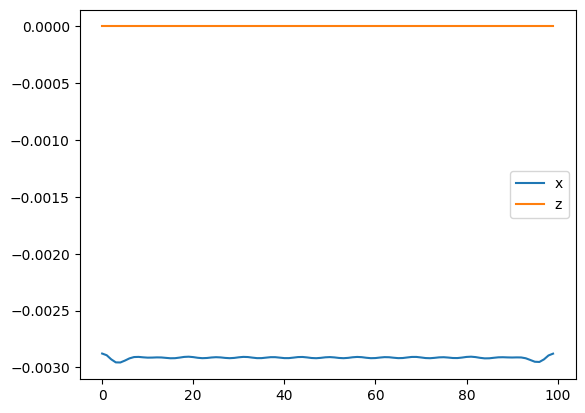

0.007554943907647002


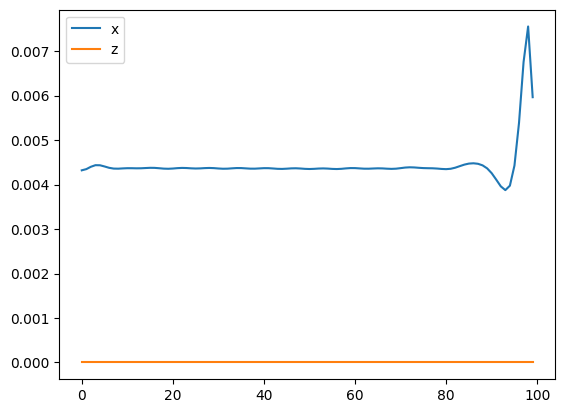

 69.0%   69 of  100 [###########################-------------] 00:20:58

In [47]:
# ---------------- Compute gradients ----------------
# map_list: shape (n_maps, 4, 4) with each 2x2 superoperator flattened
map_list = np.array(map_list, dtype=np.complex128)  # make sure 4x4 each
target_unitary = np.eye(2, dtype=np.complex128)

# numerical gradient using numdifftools

fid_val,fid_grad = fidelity_and_gradient_numpy(map_list[-1], target_unitary)

fid_grad= np.array(fid_grad).reshape(4,4,order='F')  # reshape back to 4x4

# combine derivs
fid_params=np.einsum("tpij,ij->tp",dyn_map_derivatives , fid_grad)

grad_norm = np.linalg.norm(fid_params.flatten(),ord=np.inf)

for i in range(0,fid_params.shape[0],2):
    fid_params[i,:]=fid_params[i+1,:]+fid_params[i,:]

fid_params=fid_params[0::2]

plt.plot(fid_params[:,0].real, label='x')
plt.plot(fid_params[:,1].real, label='z')
plt.legend()
plt.show()

tr_val,tr_grad = trace_and_gradient_numpy(map_list[-1], target_unitary)

tr_grad= np.array(tr_grad).reshape(4,4)  # reshape back to 4x4

# combine derivs
tr_params=np.einsum("tpij,ij->tp",dyn_map_derivatives , tr_grad)

for i in range(0,tr_params.shape[0],2):
    tr_params[i,:]=tr_params[i+1,:]+tr_params[i,:]

tr_params=tr_params[0::2]

tr_grad_norm = np.linalg.norm(tr_params.flatten(),ord=np.inf)
print(tr_grad_norm)
plt.plot(tr_params[:,0].real, label='x')
plt.plot(tr_params[:,1].real, label='z')
plt.legend()
plt.show()

In [ ]:
iteration=0

history=[]

def projected_grad(x, grad, p_bounds): 

    proj_grad = grad.copy() 
    for i, (xi, gi, bnd) in enumerate(zip(x, grad, p_bounds)): 
        lb, ub = bnd 
        if lb is not None and np.isclose(xi, lb) and gi > 0: 
            proj_grad[i] = 0.0 
        elif ub is not None and np.isclose(xi, ub) and gi < 0: 
            proj_grad[i] = 0.0 
        
    return proj_grad

# next check, do infid and grad of state fidelity using map 
def infidandgrad_numpy(paras,num_parameters,bounds=[(None,None)]):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity w.r.t. [hx0, hz0, hx1, hz1, ...]
    """

    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_parameters))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)

    # Map + derivative of map w.r.t. parameters at each time step
    maps,map_grads=map_and_grad(system,process_tensor_tebd,reshapedparas,dt,num_steps)

    # Map gradients are computed over half time steps (add together adjacent grads)
    for i in range(0,map_grads.shape[0],2): 
        map_grads[i,:]=map_grads[i,:]+ map_grads[i+1,:]
            
    map_grads=map_grads[0::2]
    
    target_unitary=np.identity(2)

    # Calculation of final map fidelity and derivative of fidelity w.r.t. final map
    # (Here can swap out trace or fidelity unitary)
    fidelity,fidelity_grad=fidelity_and_gradient_numpy(maps[-1].T,target_unitary)
    #fidelity,fidelity_grad=trace_and_gradient_numpy(maps[-1],target_unitary)
    fidelity_grad= np.array(fidelity_grad).reshape(4,4)  # reshape back to 4x4

    # Sum over matrix indices (last two axes) to get derivative w.r.t each parameter
    # Result: (num_steps, num_parameters)
    grads_per_param = np.einsum("tpij,ij->tp", map_grads, fidelity_grad)

    # Flatten to match optimizer input: [hx0, hz0, hx1, hz1, ...]
    grads_flat = grads_per_param.flatten()

    proj_grad=projected_grad(paras,grads_flat,bounds)

    proj_norm=np.linalg.norm(proj_grad,ord=np.inf)

    global iteration
    iteration+=1
    global history
    history.append((iteration,1-fidelity.real,np.linalg.norm(grads_flat.real),proj_norm))
    print("[iteration {0}], infidelity: {1}, gradient norm: {2}".format(iteration,1-fidelity.real,np.linalg.norm(grads_flat.real)))

    # Return the minus the gradient as infidelity is being minimized 
    return 1-fidelity.real,-1.0*grads_flat.real

 69.0%   69 of  100 [###########################-------------] 00:21:01

In principle, the map and map gradient should be able to reproduce the results from the state fidelity. The fidelity formula is trivially recovered by using the map to obtain the final state and inserting it into the fidelity formula. For the derivatives, they can be obtained via the chain rule: 
\begin{equation}
\frac{\partial F(\rho,\sigma)}{\partial c_\alpha (t)} = \frac{\partial F(\rho,\sigma)}{\partial \rho_f} \frac{\partial \rho_f}{\partial c_\alpha (t)} = \frac{\partial F(\rho,\sigma)}{\partial \rho_f} \frac{ \partial\Lambda(t,0)}{\partial c_\alpha (t)} \rho_0,
\end{equation}
where $F(\rho,\sigma)$ is a similarity measure, such as the fidelity, between a state $\rho$ and $\sigma$ and we have used the relation $\rho_f = \Lambda(t,0) \rho_0$

In [ ]:
num_params=2
def state_infid_grad_test(paras):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """
    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_params))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)

    maps,map_grads=map_and_grad(system,process_tensor_tebd,reshapedparas,dt,num_steps)
    
    vec_Rho=initial_state.reshape(2**2) # row major
    fs_vec=maps[-1].T@vec_Rho # transpose here yields correct fid
    fs=fs_vec.reshape((2,2))

    fidelity=np.sum(fs*target_derivative.T)

    td_vec=target_derivative.reshape(2**2)
    gps=np.einsum("tpij,i,j->tp",map_grads,vec_Rho,td_vec) # no transpose here but one above... need to check consistency of gate with gradient ordering

    # Adding adjacent elements
    for i in range(0,gps.shape[0],2): 
        gps[i,:]=gps[i,:]+gps[i+1,:]
        
    gps=gps[0::2]


    # Return the minus the gradient as infidelity is being minimized 
    return 1-fidelity.real,(-1.0*gps.reshape((-1)).real).tolist()

def state_infid_grad(paras):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """
    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_params))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)

    gradient_dict = oqupy.state_gradient(
        system=system,
        initial_state=initial_state,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_tebd],
        parameters=reshapedparas,
        num_steps=num_steps,
        progress_type='silent')
    
    
    fs=gradient_dict['final_state']
    gps=gradient_dict['gradient']
    fidelity=np.sum(fs*target_derivative.T)

    # Adding adjacent elements
    for i in range(0,gps.shape[0],2): 
        gps[i,:]=gps[i,:]+gps[i+1,:]
        
    gps=gps[0::2]

    # Return the minus the gradient as infidelity is being minimized 
    return 1-fidelity.real,(-1.0*gps.reshape((-1)).real).tolist()


 87.0%   87 of  100 [##################################------] 00:19:05

 69.0%   69 of  100 [###########################-------------] 00:22:14

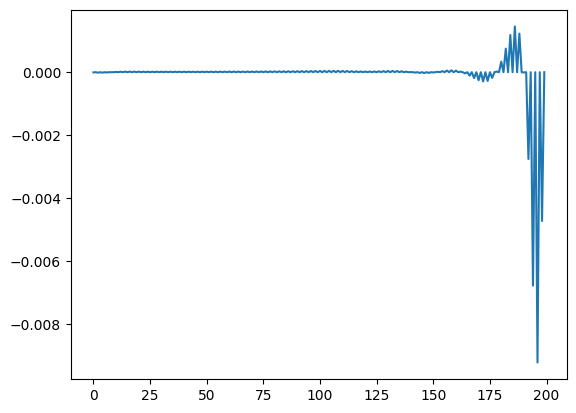

 87.0%   87 of  100 [##################################------] 00:20:36

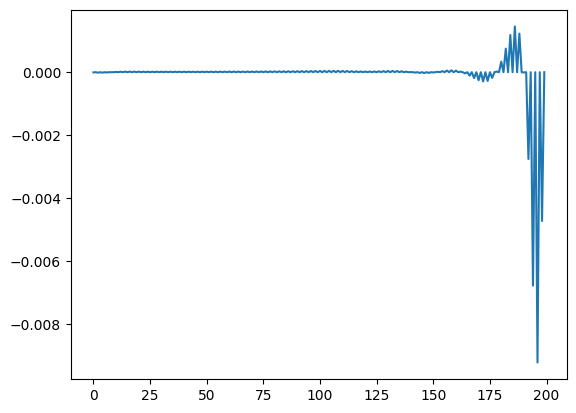

In [51]:
# sanity check by comparing state gradient 

z0 = np.zeros(num_steps)
x0 = np.ones(num_steps)*omega_cutoff

parameter_list=[item for pair in zip(x0, z0) for item in pair]
# Flatten list for input to optimizer

state_grad=state_infid_grad(np.array(parameter_list))
plt.plot(state_grad[1],label='state_infid_grad')
plt.show()

test_grad=state_infid_grad_test(np.array(parameter_list))
plt.plot(test_grad[1],label='state_infid_grad_test')
plt.show()




In [ ]:
# warning : takes ~ 250-300 minutes

x_bound = [-np.pi,np.pi]
y_bound = [-np.pi,np.pi]
z_bound = [-np.pi,np.pi]
num_parameters=2
bounds = np.zeros((num_steps*num_parameters,2))

for i in range(0, num_parameters*num_steps,num_parameters):
        bounds[i] = x_bound
        #bounds[i+1] = y_bound
        bounds[i+1] = z_bound


optimization_result_test = minimize(
                        fun=infidandgrad_numpy,
                        x0=parameter_list,
                        method='L-BFGS-B',
                        jac=True,
                        #bounds=bounds,
                        options = {'disp':True, 'gtol': 1e-5}
)



NameError: name 'infidandgrad' is not defined

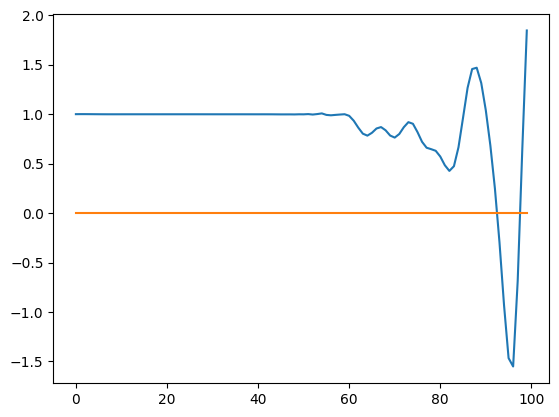

In [ ]:
reshapedparas=np.array([i for i in (np.array(optimization_result_test.x).reshape((-1,num_parameters))).tolist()])
plt.plot(reshapedparas[:,0])
plt.plot(reshapedparas[:,1])
plt.show()

In [ ]:
print("infidelity: ",1-state_infid_grad(np.array(parameter_list))[0])
print("infidelity: ",1-state_infid_grad_test(np.array(parameter_list))[0])

infidelity:  0.2620970720544398
infidelity:  0.2620970720544398
infidelity:  0.2620970720544398


In [ ]:
# numerical gradient for testing
def numerical_gradient(func, paras, eps=1e-6):

    grad = np.zeros_like(paras, dtype=float)
    for i in range(len(paras)):
        shift = np.zeros_like(paras)
        shift[i] = eps
        f_plus = func(paras + shift)[0]
        f_minus = func(paras - shift)[0]
        grad[i] = (f_plus - f_minus) / (2 * eps)
    return grad

grad = numerical_gradient(lambda x :infidandgrad_numpy(x,2), parameter_list)

[iteration 1], infidelity: 0.46155090728375225, gradient norm: 0.02669566086010062
[iteration 2], infidelity: 0.4615509196071703, gradient norm: 0.026701574575085284
[iteration 3], infidelity: 0.4615509134450222, gradient norm: 0.026698617714149327
[iteration 4], infidelity: 0.46155091344502175, gradient norm: 0.026698617714150677
[iteration 5], infidelity: 0.4615509045357242, gradient norm: 0.026695659141190976
[iteration 6], infidelity: 0.4615509223551999, gradient norm: 0.026701576293991933
[iteration 7], infidelity: 0.4615509134450211, gradient norm: 0.026698617714180386
[iteration 8], infidelity: 0.4615509134450204, gradient norm: 0.026698617714175397
[iteration 9], infidelity: 0.4615509045002405, gradient norm: 0.02669565774891041
[iteration 10], infidelity: 0.46155092239067885, gradient norm: 0.026701577686209396
[iteration 11], infidelity: 0.4615509134450215, gradient norm: 0.026698617714179685
[iteration 12], infidelity: 0.46155091344502186, gradient norm: 0.026698617714177548

[iteration 42], infidelity: 0.4615509134449933, gradient norm: 0.026698617715542824


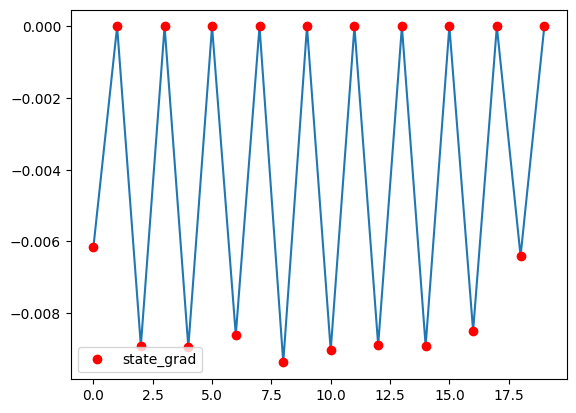

In [32]:
plt.plot(grad)
#plt.plot(fid_params,label='analyt')
plt.plot(infidandgrad_numpy(np.array(parameter_list),2)[1],'ro',label='state_grad')
plt.legend()
plt.show()

In [ ]:
# profiling (~20 seconds)

import cProfile
import pstats
import io   

pr = cProfile.Profile()
pr.enable()
fid,grad=state_infid_grad_test(np.array(parameter_list))
pr.disable()
s = io.StringIO()
sortby = 'cumulative'
ps = pstats.Stats(pr, stream=s).sort_stats(sortby)
ps.print_stats()
print(s.getvalue())

         5967438 function calls (5967436 primitive calls) in 19.038 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.001    0.000   19.053    9.527 /Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3636(run_code)
        2    0.000    0.000   19.052    9.526 {built-in method builtins.exec}
        1    0.003    0.003   19.052   19.052 /var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_867/2789696522.py:1(<module>)
        1    0.020    0.020   19.042   19.042 /var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_867/1052867446.py:2(state_infid_grad_test)
        1    0.073    0.073   19.012   19.012 /var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_867/486982685.py:1(map_and_grad)
        1    0.005    0.005   11.069   11.069 /Users/eoinoneill/Desktop/OQuPy/oqupy/gate_gradient.py:179(gate_chain_rule)
      100    0.001    0.000   10.406 

--> Compute forward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.9s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.2s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:12
Elapsed time: 12.8s
--> Compute forward propagation:
 11.0%   11 of  100 [####------------------------------------] 00:00:00

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.1s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.6s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:08
Elapsed time: 8.7s
--> Compute forward propagation:
 31.0%   31 of  100 [############----------------------------] 00:00:00

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.2s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.9s
--> Apply chain rule:
100.0%  100 of  100 [########################################] 00:00:06
Elapsed time: 6.9s


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


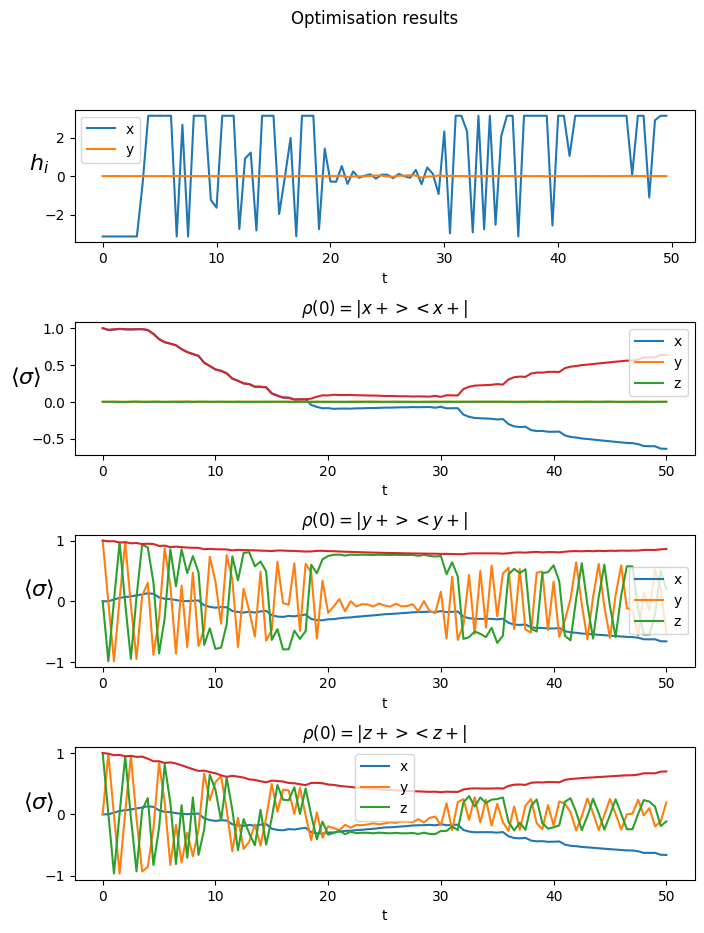

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1,figsize=(8,10)) 
fig.suptitle("Optimisation results")
fig.subplots_adjust(hspace=0.6)  # more vertical space between rows

field_labels = ["x","y","z"]
for i in range(0,num_parameters):
        axs[0].plot(t[:-1],optimization_result['x'][i::num_parameters],label=field_labels[i])
        axs[0].set_ylabel(r"$h_i$",rotation=0,fontsize=16)
        axs[0].set_xlabel("t")
        axs[0].legend()

basis_states=[op.SPIN_DM["x+"],op.SPIN_DM["y+"],op.SPIN_DM["z+"]] 
basis_labels=["|x+><x+|","|y+><y+|","|z+><z+|"]

for i,state in enumerate(basis_states):
        j=i+1
        # Input optimized controls into state_gradient to show dynamics of system under optimized fields
        optimized_dynamics = state_gradient(
                system=system,
                initial_state=np.array(state),
                target_derivative=target_derivative,
                process_tensors=[process_tensor_tebd],
                parameters=reshapedparas,
                num_steps=num_steps)

        dynamics = optimized_dynamics['dynamics']

        t, bloch_x =optimized_dynamics['dynamics'].expectations(op.sigma("x"))
        t, bloch_y = optimized_dynamics['dynamics'].expectations(op.sigma("y"))
        t, bloch_z = optimized_dynamics['dynamics'].expectations(op.sigma("z"))

        axs[j].plot(t,bloch_x,label='x')
        axs[j].plot(t,bloch_y,label='y')
        axs[j].plot(t,bloch_z,label='z')
        bloch_length = np.sqrt(bloch_x**2 +bloch_y**2 + bloch_z**2)
        axs[j].legend()
        axs[j].plot(t,bloch_length,label=r'$|\mathbf{\sigma}|$')
        axs[j].set_title(r"$\rho(0)={0}$".format(basis_labels[i]))
        axs[j].set_ylabel(r"$\langle \sigma \rangle$",rotation=0,fontsize=16)
        axs[j].set_xlabel("t")


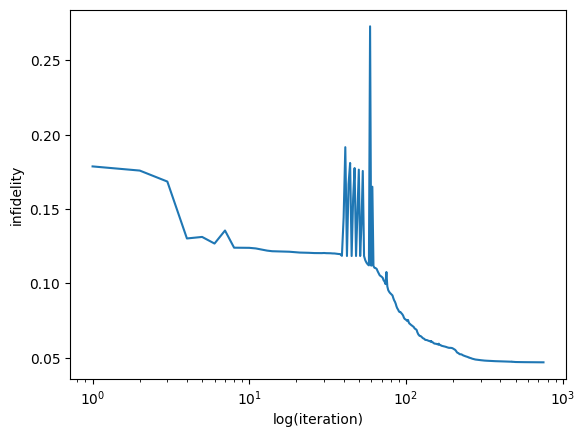

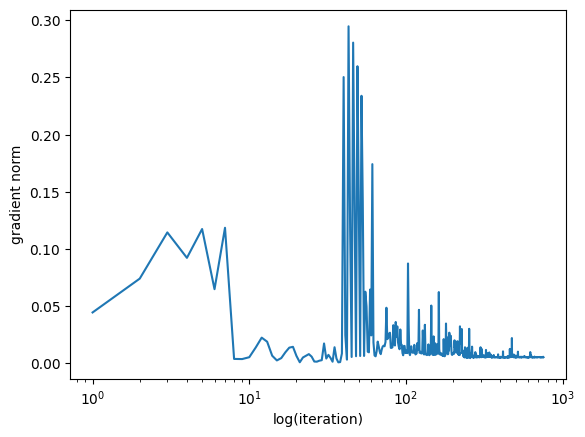

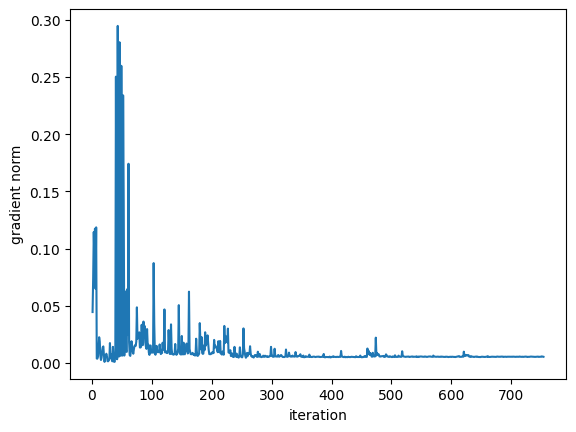

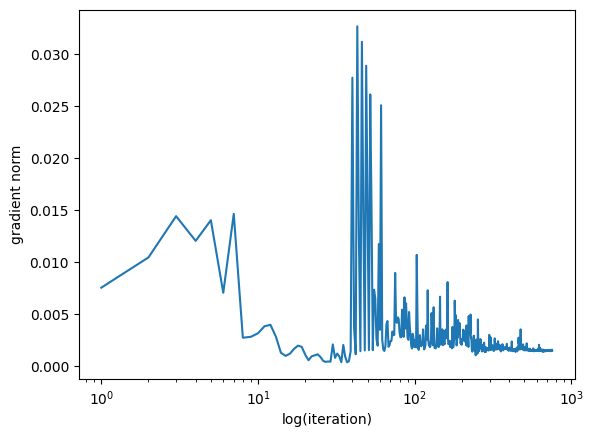

In [ ]:
hist_iter=[x[0] for x in history]
infid=[x[1] for x in history]
grads=[x[2] for x in history]
proj_grads=[x[3] for x in history]
plt.plot(hist_iter,infid,label='infidelity')
plt.xscale('log')
plt.xlabel('log(iteration)')
plt.ylabel('infidelity')
plt.show()
plt.plot(hist_iter,grads,label='gradient norm')

plt.xscale('log')
plt.ylabel('gradient norm')
plt.xlabel('log(iteration)')
plt.show()

plt.plot(hist_iter,grads,label='gradient norm')

plt.ylabel('gradient norm')
plt.xlabel('iteration')
plt.show()


plt.plot(hist_iter,proj_grads,label='projected gradient norm')
plt.ylabel('gradient norm')
plt.xlabel('log(iteration)')
plt.xscale('log')
plt.show()



In [ ]:
np.shape([x[0] for x in history])

(1193,)

In [ ]:
opt_dictionary={"optimisation_result":optimization_result,
                "history":history,
                "parameter_list":parameter_list,
                "bounds":bounds}

In [ ]:
import pickle
with open('itebd_optimization_pi_trace.pkl', 'wb') as f:
    pickle.dump(opt_dictionary, f)


In [ ]:
# TO DO 
# check code works correctly (construct state fidelity using gate code)
# implement analytic propagators and propagator derivatives
# revisit heat minimisation code - can run a simulation with better parameters/intermediate coupling
# try for trace distance as well .... should be quite different actually

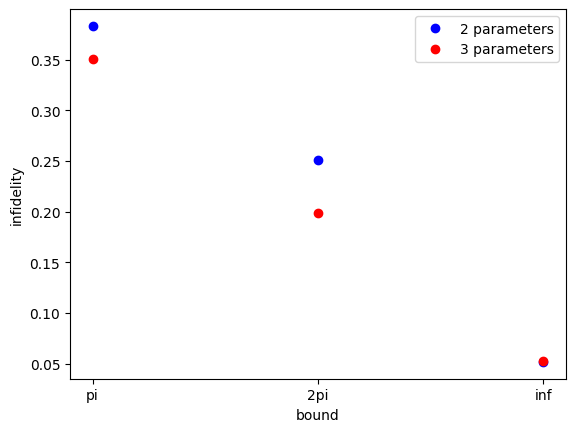

 63.0%   63 of  100 [#########################---------------] 02:22:13

In [ ]:
file_endings=["pi","2pi","NoBound","pi_3params","2pi_3params","NoBound_3params"]

results_dict={}
final_fids=[]
for i,end in enumerate(file_endings):
    with open('itebd_optimization_{}.pkl'.format(end), 'rb') as f:
        opt_dictionary = pickle.load(f)
        results_dict.update({end:opt_dictionary["optimisation_result"]})
        final_fids.append(opt_dictionary["optimisation_result"].fun)

plt.plot(final_fids[:3],'bo',label="2 parameters")
plt.plot(final_fids[3:],'ro',label="3 parameters")
plt.xticks(ticks=[0,1,2],labels=("pi","2pi","inf"))
plt.xlabel("bound")
plt.ylabel("infidelity")
plt.legend()



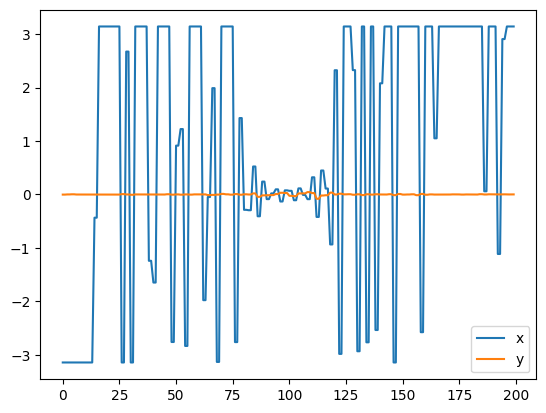

0.04697456931778987


 63.0%   63 of  100 [#########################---------------] 6 days, 7:12:468

In [ ]:
file_endings=["pi_trace"]

results_dict={}
final_fids=[]
for i,end in enumerate(file_endings):
    with open('itebd_optimization_{}.pkl'.format(end), 'rb') as f:
        opt_dictionary = pickle.load(f)
        results_dict.update({end:opt_dictionary["optimisation_result"]})
        final_fids.append(opt_dictionary["optimisation_result"].fun)

optimized_results=results_dict["pi_trace"].x
reshapedparas=np.array([i for i in (optimized_results.reshape((-1,num_parameters))).tolist() for j in range(2)])
plt.plot(reshapedparas[:,0],label='x')
plt.plot(reshapedparas[:,1],label='y')
plt.legend()
plt.show()

print(results_dict["pi_trace"].fun)
